In [823]:
import pandas as pd
import numpy as np
# ▼ 이거 쓰다가 생각해보니 시계열 예측임
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn import set_config
from xgboost import XGBRegressor

import matplotlib.pyplot as plt

from pathlib import Path

 

1. 항공기 지연 예측을 위해 제공된 항공편 데이터, 공항 데이터, 날씨 등 데이터를 불러오세요.

2. 날씨 데이터에서 결측치가 존재하는 컬럼을 확인하고, 결측치 개수를 출력하세요.

3. 날씨 데이터의 결측치를 시간 순서 기준으로 보간(interpolation) 하세요.


4. 항공편 데이터에 “출발 공항의 날씨 정보”, “도착 공항의 날씨 정보”를 각각 병합하세요. (수업시간에 배운 병합방법을 나열하고 가장 적합한 형태로 병합하세요)

5. 도착 지연 시간을 예측하기 위한 타깃 변수(target) 를 정의하세요. (그 이유를 설명하세요)

6. 모델 학습에 불필요한 컬럼을 제거하고, 학습에 사용할 입력 변수(X)를 구성하세요. (수업시간에 배운 내용을 토대로 제거한 후, 제거한 이유를 설명하세요)

7. 데이터를 학습용/테스트용으로 분리하세요.

8. XGBoost Regressor를 사용하여 모델을 학습하세요.

9. 학습된 모델을 사용하여 테스트 데이터에 대한 예측을 수행하고, 적절한 평가 지표를 출력하세요. (수업시간에 배운 내용을 토대로 평가 지표를 작성하고 데이터에 대해 인사이트를 기술하세요)

10. 모델의 Feature Importance를 시각화하고, 가장 중요한 Feature 2개를 확인하세요.

In [824]:
SEED=2026

set_config(display="text")

DATA_DIR = Path() / "data" / "머신러닝평가데이터"

DATA_FILES: dict[str, pd.DataFrame | None] = {
  "airlines": None,
  "airports": None,
  "describe": None,
  "flights": None,
  "planes": None,
  "planes": None,
  "tzone_meta": None,
  "weather": None,
}

print(DATA_DIR.resolve())

C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\03_projects\machine_learning_deep_learning_test\data\머신러닝평가데이터


# 1. 데이터 모두 불러오기

In [825]:
for name, _ in DATA_FILES.items():
  raw_df = pd.read_csv(DATA_DIR / (name+".csv"))

  print(name, "\n", raw_df.columns)
  print()
  DATA_FILES[name] = raw_df

airlines 
 Index(['carrier', 'name'], dtype='str')

airports 
 Index(['faa', 'name', 'lat', 'lon', 'alt', 'tz', 'dst', 'tzone'], dtype='str')

describe 
 Index(['Unnamed: 0', 'year_flights', 'month', 'day', 'sched_dep_time',
       'dep_delay', 'sched_arr_time', 'arr_delay', 'flight', 'air_time',
       'distance', 'hour', 'minute', 'lat', 'lon', 'alt', 'tz', 'tzone',
       'year_planes', 'engines', 'seats', 'year', 'month_weather',
       'day_weather', 'hour_weather', 'wind_speed', 'wind_gust', 'visib'],
      dtype='str')

flights 
 Index(['year', 'month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay',
       'arr_time', 'sched_arr_time', 'arr_delay', 'carrier', 'flight',
       'tailnum', 'origin', 'dest', 'air_time', 'distance', 'hour', 'minute',
       'time_hour'],
      dtype='str')

planes 
 Index(['tailnum', 'year', 'type', 'manufacturer', 'model', 'engines', 'seats',
       'speed', 'engine'],
      dtype='str')

tzone_meta 
 Index(['tzone', 'tzone_name'], dtype='str')



### (요구사항x) 데이터셋 확인
> 전체적인 컬럼들 확인하면서 대강 써보기
- airlines: 항공사
  - carrier: 항공사 코드
  - name: 이름
- airports: 공항
  - faa: 공함 코드
  - name: 공항 이름
  - lat: 위도
  - lon: 경도
  - alt: 고도
  - tz: UTC 기준 시간 오프셋
  - dst: DaySavingTime이라는 일광절약시가제(?) 구분
  - tzone: 타임존으로 추정
- describe: 연도나 등등 뭔가 많음 (아마 통계치로 추정)
- flights: 비행기가 비행을 시작하거나 지연된 시간, 항공사 등을 이야기 하는 듯 함. 여기에 carrier 컬럼도 있음. 
- planes: tailnum이라는 기종 번호와 함께 year 이라는 아마 제작 년도로 추정되는 데이터가 있음. 또한 모델, 엔진, 좌석 등이 있음. 주요하게 속도가 좀 비어있는걸로 보이는데 이따 통계 한번 직접 내보면서 확인할 부분
- tzone_meta: timezone에 대한 메타정보인듯. tzone 이름에 대한 인덱스 번호가 붙어있는 것으로 보임
- weather: 날씨데이터로 origin에 공항 코드가 있고, 날씨 컬럼에 대해서 결측치가 많은데 이게 관측할 필요가 없었던 것인지 아니면 진짜 관측을 못한 것인지 또는 NaN 자체가 무슨 의미가 있는 것인지는 알아보아야함.

> 아래 숫자를 살펴보면 `airlines`, `describe`, `tzone_meta` 같은 join 하기 좋은 데이터가 존재함. 이다가 4번에 쓰이는 것으로 보임.

In [826]:
for name, df in DATA_FILES.items():
  print(name, len(df))

airlines 12
airports 1333
describe 8
flights 303748
planes 3521
tzone_meta 10
weather 26201


# 2. 날씨 데이터 결측치 확인

In [827]:
df = DATA_FILES["weather"]

# 아래 결과를 보면 ttemp, dewp, humid 등과 같은 결측치가 많고, 
# visib는 11개의 결측치가 있음 (아마 가시거리? 일까 싶음)
df.isna().sum()

origin            0
year              0
month             0
day               0
hour              0
temp          25642
dewp          25642
humid         25642
wind_dir       2661
wind_speed     2647
wind_gust      2647
precip        24831
pressure      25768
visib            11
time_hour         0
dtype: int64

# 3. 날씨 데이터 시간순으로 보간하기
> 그런데 26201 중에서 대부분이 결측치인 것들이 많아서 이걸 어떻게 해야할지 모르겠음.
그냥 막 만들어도 되는건가? 일단 항공사별로 나눠서 보자.

In [828]:
ISNA_DATAS = ["temp","dewp","humid","wind_dir","wind_speed","wind_gust","precip","pressure","visib"]

# 총 개수에서 빼보기 (결측치 겁나많음. 골고루 많음.)
26201 - \
  df.groupby("origin")[["temp","dewp","humid","wind_dir","wind_speed","wind_gust","precip","pressure","visib"]].count()

,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib
origin,,,,,,,,,
EWR,25997,25997,25997,18095,18083,18083,25732,26030,17469
JFK,26028,26028,26028,18340,18338,18338,25754,26080,17468
LGA,26019,26019,26019,18628,18628,18628,25747,26060,17476


In [829]:
df.groupby("origin")[["temp","dewp","humid","wind_dir","wind_speed","wind_gust","precip","pressure","visib"]].count()

,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib
origin,,,,,,,,,
EWR,204,204,204,8106,8118,8118,469,171,8732
JFK,173,173,173,7861,7863,7863,447,121,8733
LGA,182,182,182,7573,7573,7573,454,141,8725


다른 변수를 이용해서 구해야하는건가? 기압이나 등등 공분산 계산하는걸 생각해보긴 했는데 정말 결측치가 골고루 있어서 그냥 비어있는 값들, 예를 들어서

a - nan - nan - nan - b 이면

`a - [a*0.75 + b*0.25] - [a*0.5 + b*0.5] - [a*0.25 + b*0.75] - b` 방식으로 하는게 맞을듯?

In [830]:
# 시간으로 만들어서 정렬해주기
df["time_hour"] = pd.to_datetime(df["time_hour"])

df = df.sort_values(
  ["origin", "time_hour"]
)

df[["time_hour"]].head(), df[["time_hour"]].tail()

(            time_hour
 0 2017-01-01 08:00:00
 1 2017-01-01 09:00:00
 2 2017-01-01 10:00:00
 3 2017-01-01 11:00:00
 4 2017-01-01 12:00:00,
                 time_hour
 26196 2017-12-31 03:00:00
 26197 2017-12-31 04:00:00
 26198 2017-12-31 05:00:00
 26199 2017-12-31 06:00:00
 26200 2017-12-31 07:00:00)

In [831]:
# 시간 간격으로 계산

# transform 메서드에 들어갈 결측치 사이를 보간하는 방식에 들어갈 콜백 함수를 등록
def interpolate_weather(group):
  # groupkey로 묶인 컬럼 나중에 합쳐주기
  origin = group.name

  # 시간을 인덱스로 삼아서 더 정확하게 보간
  group = group.sort_values("time_hour")
  group = group.set_index("time_hour")
  group[ISNA_DATAS] = group[ISNA_DATAS].interpolate(method="time", limit_direction="both")


  group = group.reset_index()

  group["origin"] = origin

  return group

df = (
  df.groupby("origin", group_keys=False).apply(interpolate_weather)
)

In [832]:
df

,time_hour,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,origin
0,2017-01-01 08:00:00,2017.0,1.0,1,0,42.1,39.9,91.84,200.0,17.26170,19.864419,0.01,1009.6,10.0,EWR
1,2017-01-01 09:00:00,2017.0,1.0,1,1,42.1,39.9,91.84,220.0,16.11092,18.540125,0.01,1009.6,10.0,EWR
2,2017-01-01 10:00:00,2017.0,1.0,1,2,42.1,39.9,91.84,190.0,11.50780,13.242946,0.01,1009.6,10.0,EWR
3,2017-01-01 11:00:00,2017.0,1.0,1,3,42.1,39.9,91.84,190.0,8.05546,9.270062,0.01,1009.6,10.0,EWR
4,2017-01-01 12:00:00,2017.0,1.0,1,4,42.1,39.9,91.84,220.0,9.20624,10.594357,0.01,1009.6,10.0,EWR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8728,2017-12-31 03:00:00,2017.0,12.0,30,19,26.1,21.9,83.89,210.0,9.20624,10.594357,0.01,1017.1,5.0,LGA
8729,2017-12-31 04:00:00,2017.0,12.0,30,20,26.1,21.9,83.89,200.0,10.35702,11.918651,0.01,1017.1,10.0,LGA
8730,2017-12-31 05:00:00,2017.0,12.0,30,21,26.1,21.9,83.89,280.0,8.05546,9.270062,0.01,1017.1,10.0,LGA
8731,2017-12-31 06:00:00,2017.0,12.0,30,22,26.1,21.9,83.89,260.0,10.35702,11.918651,0.01,1017.1,10.0,LGA


In [833]:
print(df.isna().sum())

time_hour     0
year          0
month         0
day           0
hour          0
temp          0
dewp          0
humid         0
wind_dir      0
wind_speed    0
wind_gust     0
precip        0
pressure      0
visib         0
origin        0
dtype: int64


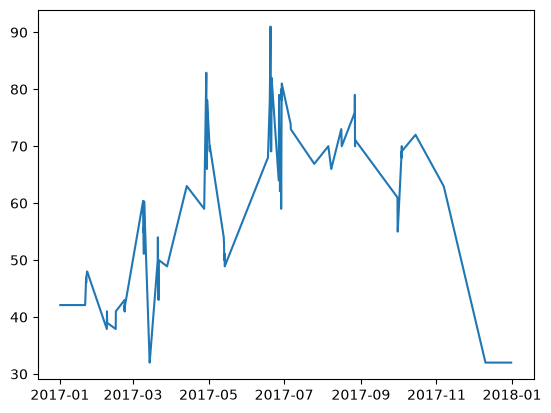

In [834]:
# 시각화로 온도 정도만 잘 만들어졌는지 확인
plt.plot(df[df["origin"]=="EWR"]["time_hour"], df[df["origin"]=="EWR"]["temp"])
plt.show()

# 4. 출발/도착 공항의 날씨정보 병합
수업때 배웠던 병합 방법
- join
- merge
- concat

선택:

개인적으로 join 방식이 익숙하고 직관적이여서 하려했는데 sql join은 pd의 merge와 더 가까워서 merge 방식 사용

In [835]:
# 아래 정보에서 동일한 비행 id와 출발인지 도착인지를 비교해서 구하면 될듯
DATA_FILES["flights"].columns

Index(['year', 'month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay',
       'arr_time', 'sched_arr_time', 'arr_delay', 'carrier', 'flight',
       'tailnum', 'origin', 'dest', 'air_time', 'distance', 'hour', 'minute',
       'time_hour'],
      dtype='str')

In [836]:
# 동일 식별자는 flight이고
# 출발지: origin

# 실제 출발 시간(분): de_time
# 예정상 출발 시간(분): sched_dep_time
# 지연된 시간(분): dep_delay

# 도착지: dest

# 실제 도착 시간: arr_time
# 예정 도착 시간: sched_arr_time
# 지연 시간: arr_delay

flights = DATA_FILES["flights"]
flights.head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2017,10,1,27.0,2114,193.0,317.0,15,182.0,UA,1537,N54711,EWR,MIA,148.0,1085.0,21.0,14.0,2017-10-01 21:00:00
1,2017,10,1,519.0,525,-6.0,741.0,759,-18.0,UA,1161,N37287,EWR,IAH,183.0,1400.0,5.0,25.0,2017-10-01 05:00:00
2,2017,10,1,544.0,545,-1.0,815.0,819,-4.0,B6,27,N547JB,EWR,MCO,133.0,937.0,5.0,45.0,2017-10-01 05:00:00
3,2017,10,1,546.0,550,-4.0,702.0,719,-17.0,UA,761,N38446,LGA,ORD,108.0,733.0,5.0,50.0,2017-10-01 05:00:00
4,2017,10,1,552.0,600,-8.0,846.0,850,-4.0,NK,521,N675NK,EWR,FLL,156.0,1065.0,6.0,0.0,2017-10-01 06:00:00


In [837]:
weather = df
weather.head()

,time_hour,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,origin
0,2017-01-01 08:00:00,2017.0,1.0,1,0,42.1,39.9,91.84,200.0,17.26170,19.864419,0.01,1009.6,10.0,EWR
1,2017-01-01 09:00:00,2017.0,1.0,1,1,42.1,39.9,91.84,220.0,16.11092,18.540125,0.01,1009.6,10.0,EWR
2,2017-01-01 10:00:00,2017.0,1.0,1,2,42.1,39.9,91.84,190.0,11.50780,13.242946,0.01,1009.6,10.0,EWR
3,2017-01-01 11:00:00,2017.0,1.0,1,3,42.1,39.9,91.84,190.0,8.05546,9.270062,0.01,1009.6,10.0,EWR
4,2017-01-01 12:00:00,2017.0,1.0,1,4,42.1,39.9,91.84,220.0,9.20624,10.594357,0.01,1009.6,10.0,EWR


In [838]:
# 비교 병합을 위해 모두 datetime 타입으로 변환하기
flights["time_hour"] = pd.to_datetime(flights["time_hour"])
weather["time_hour"] = pd.to_datetime(weather["time_hour"])

# flights에 weather 정보 병합해주기.
# flights.dest = weather.origin 으로 *_dest_weather
# flights.origin = weather.origin 으로 *_origin_weather 붙여주기

df = flights.merge(
    weather.rename(
      columns = {
        col: f"{col}_origin_weather"
        for col in weather.columns
        if col not in ["origin", "time_hour"]
      }
    ),
    how="left", # flights를 기준으로 오른쪽이 없으면 drop
    on=["origin", "time_hour"], # weather의 origin과 time_hour이 동일하면 붙여주기
)

df = df.merge(
    weather.rename(
      columns = {
        col: f"{col}_dest_weather" if col != "origin" else "dest"
        for col in weather.columns
        if col not in ["time_hour"]
      }
    ),
    how="left", # flights를 기준으로 오른쪽이 없으면 drop
    on=["dest", "time_hour"], # weather의 origin과 time_hour이 동일하면 붙여주기
)

df.columns, flights.columns

(Index(['year', 'month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay',
        'arr_time', 'sched_arr_time', 'arr_delay', 'carrier', 'flight',
        'tailnum', 'origin', 'dest', 'air_time', 'distance', 'hour', 'minute',
        'time_hour', 'year_origin_weather', 'month_origin_weather',
        'day_origin_weather', 'hour_origin_weather', 'temp_origin_weather',
        'dewp_origin_weather', 'humid_origin_weather',
        'wind_dir_origin_weather', 'wind_speed_origin_weather',
        'wind_gust_origin_weather', 'precip_origin_weather',
        'pressure_origin_weather', 'visib_origin_weather', 'year_dest_weather',
        'month_dest_weather', 'day_dest_weather', 'hour_dest_weather',
        'temp_dest_weather', 'dewp_dest_weather', 'humid_dest_weather',
        'wind_dir_dest_weather', 'wind_speed_dest_weather',
        'wind_gust_dest_weather', 'precip_dest_weather',
        'pressure_dest_weather', 'visib_dest_weather'],
       dtype='str'),
 Index(['year', 'month', 'day', '

In [839]:
len(df)

303748

In [840]:
df.isna().sum()

year                              0
month                             0
day                               0
dep_time                       7810
sched_dep_time                    0
dep_delay                      7814
arr_time                       8148
sched_arr_time                    0
arr_delay                      8852
carrier                           0
flight                            0
tailnum                         991
origin                            0
dest                              0
air_time                       8852
distance                          0
hour                              0
minute                            0
time_hour                         0
year_origin_weather             777
month_origin_weather            777
day_origin_weather              777
hour_origin_weather             777
temp_origin_weather             777
dewp_origin_weather             777
humid_origin_weather            777
wind_dir_origin_weather         777
wind_speed_origin_weather   

In [841]:
weather["origin"].unique(), "", flights["dest"].unique(), "", flights["origin"].unique(), 

(<StringArray>
 ['EWR', 'JFK', 'LGA']
 Length: 3, dtype: str,
 '',
 <StringArray>
 ['MIA', 'IAH', 'MCO', 'ORD', 'FLL', 'LAX', 'DFW', 'ATL', 'MDW', 'BUF',
  ...
  'JAC', 'MTJ', 'HDN', 'STT', 'TUS', 'FNT', 'ANC', 'HYA', 'ILM', 'TVC']
 Length: 109, dtype: str,
 '',
 <StringArray>
 ['EWR', 'LGA', 'JFK']
 Length: 3, dtype: str)

# 4번 진행 도중 문제 확인
목적지 dest가 weather이 저장되어있는 정보하고 하나도 맞지 않은데 다른 메타 테이블하고 연결되어있는건지 아니면 원래 의도가 안맞는건지를 확인해야함.

> csv 직접 확인후: 없는 것으로 추정됨. 나중에 코드 보기 전에 한번 자르고 가야할 듯 함.

# 5. 도착 지연 시간 예측하기 위한 타깃 변수
일단 바로 드는 생각은 `arr_delay` 인데 이걸 묻는 이유가 `dep_delay`하고 같이 보라는 뜻이여서 그런건가? 아니면 데이터 누수 관련해서 `sched_arr_time`, `arr_time` 등을 고려하라는 의미인가?

혹시 `dep_delay` + `arr_delay`를 봐야하나

데이터를 잠깐 봐야할 듯 하다.

> 보고 생각한 결과 `arr_delay`만으로 가는 것이 맞다 판단하였습니다.

In [842]:
df.columns

Index(['year', 'month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay',
       'arr_time', 'sched_arr_time', 'arr_delay', 'carrier', 'flight',
       'tailnum', 'origin', 'dest', 'air_time', 'distance', 'hour', 'minute',
       'time_hour', 'year_origin_weather', 'month_origin_weather',
       'day_origin_weather', 'hour_origin_weather', 'temp_origin_weather',
       'dewp_origin_weather', 'humid_origin_weather',
       'wind_dir_origin_weather', 'wind_speed_origin_weather',
       'wind_gust_origin_weather', 'precip_origin_weather',
       'pressure_origin_weather', 'visib_origin_weather', 'year_dest_weather',
       'month_dest_weather', 'day_dest_weather', 'hour_dest_weather',
       'temp_dest_weather', 'dewp_dest_weather', 'humid_dest_weather',
       'wind_dir_dest_weather', 'wind_speed_dest_weather',
       'wind_gust_dest_weather', 'precip_dest_weather',
       'pressure_dest_weather', 'visib_dest_weather'],
      dtype='str')

In [843]:
df[[
"dep_time",
"sched_dep_time",
"dep_delay",
"arr_time", 
"sched_arr_time",
"arr_delay",
]].head()

,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay
0,27.0,2114,193.0,317.0,15,182.0
1,519.0,525,-6.0,741.0,759,-18.0
2,544.0,545,-1.0,815.0,819,-4.0
3,546.0,550,-4.0,702.0,719,-17.0
4,552.0,600,-8.0,846.0,850,-4.0


`sched_*_time`은 보니까 시간 형식이 HH:MM 형식이였네.

그런데 아무튼 문제 자체가 **항공기 도착 지연 시간 예측**이기 때문에 `arr_delay`로 고정하고 나머지 컬럼을 살짝실 조정해주면 될 듯 함.

또한 실제 `dep_time`이나 `dep_delay`는 미리 알 수 없기 때문에 이건 없이 가는게 맞을 듯.

# 6. 컬럼 조정 및 X 생성 (하는김에 y도)
수업 시간에 배웠던 내용으로는 **데이터 누수**는 확실하고 의미가 약한 컬럼 같은것들 제거하면서 중복되는 정보도 제거하는 느낌으로 기억함.

또한 범주형은 원핫인코딩을 해주어야하며 (그런데 하다가 생각났는데 부스팅 모델이여서 굳이 필수는 아닌거같음. 이라고 생각했지만 문자형 범주라 그냥 원핫 인코딩 해주기 )

원핫 인코딩 대상
- carrier (항공사 - 12개)
- origin - 3개
- dest - 109개 (최종 전체 데이터 294121개에 비해서 무난하여 그대로 원핫 인코딩)

예외적으로 year 컬럼은 지울까 했는데 미래를 위해 남겨둠. 모델에 큰 영향도 없을거같아서

데이터 보다 알게 된 점으로 arr_delay 값이 NaN인 아마 도착이 안된 기록도 함께 제거해주어야함

In [844]:
# 1. 우선 아까 판단한 dest 컬럼 제거
df = df.drop(columns=df.columns[df.isna().sum() == len(df)])
df.isna().sum()

year                            0
month                           0
day                             0
dep_time                     7810
sched_dep_time                  0
dep_delay                    7814
arr_time                     8148
sched_arr_time                  0
arr_delay                    8852
carrier                         0
flight                          0
tailnum                       991
origin                          0
dest                            0
air_time                     8852
distance                        0
hour                            0
minute                          0
time_hour                       0
year_origin_weather           777
month_origin_weather          777
day_origin_weather            777
hour_origin_weather           777
temp_origin_weather           777
dewp_origin_weather           777
humid_origin_weather          777
wind_dir_origin_weather       777
wind_speed_origin_weather     777
wind_gust_origin_weather      777
precip_origin_

In [845]:
# 2. weather 결측치들은 제거해주고, sched_dep_time 제외하고 시간 관련은 모두 제거
# 날짜 관련 제거중에서 시계열로 바꿀 수 있을 만한건 살려주기
df = df[~df[[c for c in df.columns if c.endswith("_origin_weather")]].isna().all(axis=1)]
df.head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,...,hour_origin_weather,temp_origin_weather,dewp_origin_weather,humid_origin_weather,wind_dir_origin_weather,wind_speed_origin_weather,wind_gust_origin_weather,precip_origin_weather,pressure_origin_weather,visib_origin_weather
0,2017,10,1,27.0,2114,193.0,317.0,15,182.0,UA,...,14.0,60.127273,49.300000,69.199091,10.0,8.055460,9.270062,0.0,1024.690909,10.0
1,2017,10,1,519.0,525,-6.0,741.0,759,-18.0,UA,...,22.0,57.197403,49.071429,75.285325,290.0,15.420452,17.745548,0.0,1020.638961,10.0
2,2017,10,1,544.0,545,-1.0,815.0,819,-4.0,B6,...,22.0,57.197403,49.071429,75.285325,290.0,15.420452,17.745548,0.0,1020.638961,10.0
3,2017,10,1,546.0,550,-4.0,702.0,719,-17.0,UA,...,22.0,59.302597,50.000000,71.735455,360.0,19.563260,22.513008,0.0,1020.370130,10.0
4,2017,10,1,552.0,600,-8.0,846.0,850,-4.0,NK,...,23.0,57.380519,49.085714,74.904935,220.0,14.729984,16.950971,0.0,1020.892208,10.0


In [846]:
df.isna().sum()

year                            0
month                           0
day                             0
dep_time                     7808
sched_dep_time                  0
dep_delay                    7812
arr_time                     8146
sched_arr_time                  0
arr_delay                    8850
carrier                         0
flight                          0
tailnum                       990
origin                          0
dest                            0
air_time                     8850
distance                        0
hour                            0
minute                          0
time_hour                       0
year_origin_weather             0
month_origin_weather            0
day_origin_weather              0
hour_origin_weather             0
temp_origin_weather             0
dewp_origin_weather             0
humid_origin_weather            0
wind_dir_origin_weather         0
wind_speed_origin_weather       0
wind_gust_origin_weather        0
precip_origin_

In [847]:
# arr_delay = NaN인 행 모두 삭제해주기
df = df[~df["arr_delay"].isna()]
df.isna().sum()

year                         0
month                        0
day                          0
dep_time                     0
sched_dep_time               0
dep_delay                    0
arr_time                     0
sched_arr_time               0
arr_delay                    0
carrier                      0
flight                       0
tailnum                      0
origin                       0
dest                         0
air_time                     0
distance                     0
hour                         0
minute                       0
time_hour                    0
year_origin_weather          0
month_origin_weather         0
day_origin_weather           0
hour_origin_weather          0
temp_origin_weather          0
dewp_origin_weather          0
humid_origin_weather         0
wind_dir_origin_weather      0
wind_speed_origin_weather    0
wind_gust_origin_weather     0
precip_origin_weather        0
pressure_origin_weather      0
visib_origin_weather         0
dtype: i

In [848]:
# 결과값 받아놓기
# 시간순 정렬
df = df.sort_values(
    ["year", "month", "day", "hour", "minute"]
).reset_index(drop=True)

y = df["arr_delay"]
y[:4]

0   -31.0
1    -8.0
2   -25.0
3   -23.0
Name: arr_delay, dtype: float64

In [849]:
# 정수이니까 //, % 연산 가능
df["sched_arr_time"].dtype

dtype('int64')

In [850]:
# 예측 시점에 못쓰는 값 제거하기
df = df.drop(columns=[
  "dep_time", "dep_delay", "arr_time", "air_time", # 예측시에 알 수 없는 값 삭제
  # 도착시에 알 수 있는 값
  "year_origin_weather",
  "month_origin_weather",
  "day_origin_weather",
  "hour_origin_weather",
  "sched_dep_time",
  
  "sched_dep_time", # year, hour, minuate,로 사용 가능 
  "flight", "tailnum", # 식별자 삭제
  "arr_delay", # 정답라벨 삭제
  "time_hour", # 트리 관점에서 year/month/day/hour/minuate가 더 좋게 느껴짐
])

# 예정 시간 분리
df["sched_arr_hour"] = df["sched_arr_time"] // 100
df["sched_arr_minute"] = df["sched_arr_time"] % 100
df = df.drop(columns="sched_arr_time")

In [851]:
# 범주형 원핫 인코딩
df = pd.get_dummies(
    df,
    columns=["carrier", "origin", "dest"],
    dtype=int
)

In [852]:


"""
# 결과
## 시간
'year', 'month', 'day', 'hour', 'minute'

## 예정 및 범주형
'distance', 
'origin_*', 
'dest_*',
'carrier_*'

## 출발 시 날씨
'temp_origin_weather', 'dewp_origin_weather', 'humid_origin_weather',
'wind_dir_origin_weather', 'wind_speed_origin_weather', 'wind_gust_origin_weather', 
'precip_origin_weather', 'pressure_origin_weather', 'visib_origin_weather'
"""
[c for c in df.columns if not (c.startswith("dest") or c.startswith("carrier"))]

['year',
 'month',
 'day',
 'distance',
 'hour',
 'minute',
 'temp_origin_weather',
 'dewp_origin_weather',
 'humid_origin_weather',
 'wind_dir_origin_weather',
 'wind_speed_origin_weather',
 'wind_gust_origin_weather',
 'precip_origin_weather',
 'pressure_origin_weather',
 'visib_origin_weather',
 'sched_arr_hour',
 'sched_arr_minute',
 'origin_EWR',
 'origin_JFK',
 'origin_LGA']

# 7. 데이터를 학습용/테스트용으로 분리하세요.
생각해볼 부분은 대체로 데이터는 날씨와 관련되어있지만 시계열 데이터가 있음에 따라 이를 나누어서 사용하면 좋을 것 같습니다.

* 그런데 시계열로 해보니까 r2 점수가 음수로 나와서 랜덤 추출을 해보니 또 성능이 좋지는 않아도 양수로 나왔습니다.

In [853]:
X = df

X.head()

,year,month,day,distance,hour,minute,temp_origin_weather,dewp_origin_weather,humid_origin_weather,wind_dir_origin_weather,...,dest_SNA,dest_SRQ,dest_STL,dest_STT,dest_SYR,dest_TPA,dest_TUS,dest_TVC,dest_TYS,dest_XNA
0,2017,1,1,937.0,8.0,0.0,42.1,39.9,91.84,200.0,...,0,0,0,0,0,0,0,0,0,0
1,2017,1,1,1028.0,8.0,0.0,28.9,19.9,68.67,220.0,...,0,0,0,0,0,0,0,0,0,0
2,2017,1,1,1096.0,8.0,0.0,44.1,41.0,88.77,200.0,...,0,0,0,0,0,0,0,0,0,0
3,2017,1,1,1085.0,8.0,0.0,42.1,39.9,91.84,200.0,...,0,0,0,0,0,0,0,0,0,0
4,2017,1,1,282.0,8.0,0.0,42.1,39.9,91.84,200.0,...,0,0,0,0,0,0,0,0,0,0


In [854]:
y.head()

0   -31.0
1    -8.0
2   -25.0
3   -23.0
4     9.0
Name: arr_delay, dtype: float64

In [855]:
len(X) == len(y)

True

In [856]:
# 인덱스 나눠주기
split_idx = np.linspace(0, len(X), 5).astype(int)

train_range = int(split_idx[0]), int(split_idx[3])
test_range = int(split_idx[3]), int(split_idx[4])

X_train = X[train_range[0]:train_range[1]]
y_train = y[train_range[0]:train_range[1]]

X_test = X[test_range[0]:test_range[1]]
y_test = y[test_range[0]:test_range[1]]

split_idx

array([     0,  73530, 147060, 220590, 294121])

# 8. XGBoost Regressor을 통한 학습

In [857]:
model = XGBRegressor(
  n_estimators=300, # 300개 트리
  learning_rate=0.05,
  max_depth=6,
  random_state=SEED
)

In [858]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

# 9. 예측 및 평가 지표 출력
회귀이니까 mae, rmse, r2 지표로

In [859]:
train_pred = model.predict(X_train)

mae = mean_absolute_error(y_train, train_pred)
rmse = root_mean_squared_error(y_train, train_pred)
r2 = r2_score(y_train, train_pred)

print("train")
print(f"mae: {mae:.4f}, rmse: {rmse:.4f}, r2: {r2:.4f}")

train
mae: 27.2819, rmse: 48.7504, r2: 0.3000


In [860]:
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("test")
print(f"mae: {mae:.4f}, rmse: {rmse:.4f}, r2: {r2:.4f}")
print("2026-09-07 12:36:46 기준 결과가 음수여서 아래에 추가적으로 다른 데이터 분할 방식으로 실험한 내용이 존재합니다.")

test
mae: 29.3597, rmse: 46.6435, r2: -0.0773
2026-09-07 12:36:46 기준 결과가 음수여서 아래에 추가적으로 다른 데이터 분할 방식으로 실험한 내용이 존재합니다.


# 10. Feature Importance 출력
결과 미리보기
1. origin_EWR: 0.034729
2. hour: 0.028696

In [861]:
print(len(X.columns))
print(len(model.feature_importances_))

141
141


In [862]:
importance_df = pd.DataFrame({
  "feature_name": X.columns,
  "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head()

,feature_name,importance
4,hour,0.055389
74,dest_GSP,0.034864
14,visib_origin_weather,0.026828
21,carrier_EV,0.025956
9,wind_dir_origin_weather,0.020589


# 시각화

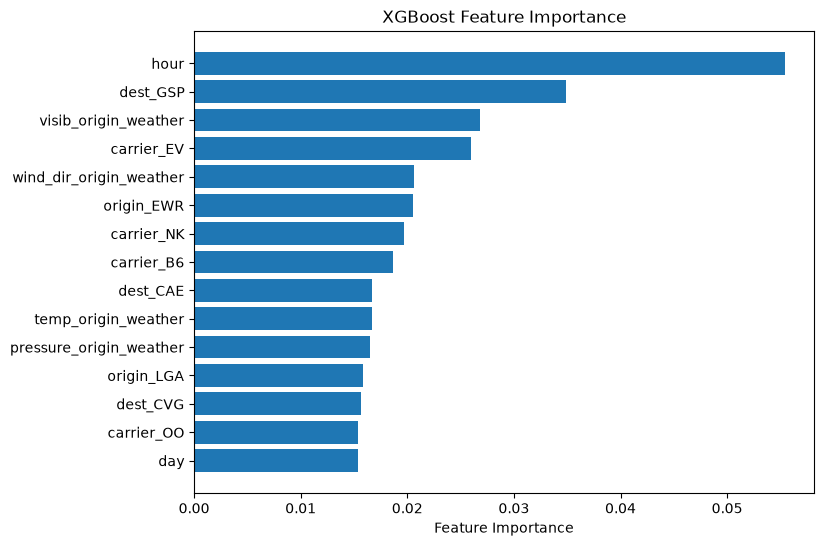

In [863]:
import matplotlib.pyplot as plt

features_to_show = 15

# df에서 상위 15개 뽑아주기
plot_df = importance_df.head(features_to_show).sort_values("importance")

# figure 그려서 만들어주기
plt.figure(figsize=(8, 6))
# 막대 그래프로 보여주기
plt.barh(plot_df["feature_name"], plot_df["importance"])
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importance")
plt.show()

# R2 결과가 음수로 나와서 시계열 없이 테스트

In [864]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=SEED
)

In [865]:
model = XGBRegressor(
  n_estimators=300, # 300개 트리
  learning_rate=0.05,
  max_depth=6,
  random_state=SEED
)

model.fit(X_train, y_train)

train_pred = model.predict(X_train)

mae = mean_absolute_error(y_train, train_pred)
rmse = root_mean_squared_error(y_train, train_pred)
r2 = r2_score(y_train, train_pred)

print("train")
print(f"mae: {mae:.4f}, rmse: {rmse:.4f}, r2: {r2:.4f}")

train
mae: 26.1637, rmse: 46.5940, r2: 0.2937


In [866]:
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("test")
print(f"mae: {mae:.4f}, rmse: {rmse:.4f}, r2: {r2:.4f}")

test
mae: 26.7000, rmse: 48.5883, r2: 0.2208


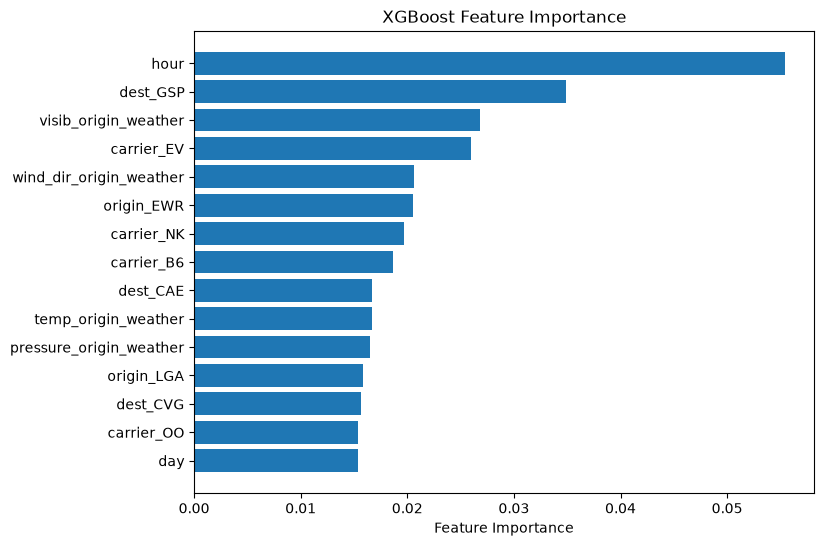

In [867]:
import matplotlib.pyplot as plt

features_to_show = 15

# df에서 상위 15개 뽑아주기
plot_df = importance_df.head(features_to_show).sort_values("importance")

# figure 그려서 만들어주기
plt.figure(figsize=(8, 6))
# 막대 그래프로 보여주기
plt.barh(plot_df["feature_name"], plot_df["importance"])
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importance")
plt.show()

# 결론
데이터 분할을 다르게 해보니 r2는 제대로 나왔지만 결국 사용한 데이터는 같고, 피처 중요도도 거의 동일한 크기를 보여주기 때문에 아직 모델을 개선할 여지가 있다고 생각할 수 있습니다.

하지만 시간이 없기 때문에 여기까지 하는 것으로 마무리하겟습니다